# **Phase 7 — Multimodal Fusion Emotion Recognition Pipeline**

This phase combines:

- acoustic emotional representations
- semantic contextual representations

to build a unified multimodal emotion recognition framework.

The multimodal pipeline integrates:

- speech embeddings
- text embeddings

to improve emotional robustness and multimodal understanding.

# Importing Required Libraries

This section imports all libraries required for:

- multimodal fusion learning
- embedding integration
- deep learning
- evaluation
- visualization

In [ ]:
import os
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import (
    DistilBertTokenizer,
    DistilBertModel
)

import librosa

# Loading Metadata and Label Encoder

The metadata dataframe and label encoder are loaded to maintain consistent multimodal label mappings.

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition"

metadata_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "tess_metadata.csv"
)

label_encoder_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "label_encoder.pkl"
)

# Load Metadata
df = pd.read_csv(metadata_path)

# Load Label Encoder
with open(label_encoder_path, "rb") as file:

    label_encoder = pickle.load(file)

print("Metadata Loaded Successfully")

Metadata Loaded Successfully


# Creating Train / Validation / Test Splits

Consistent splits are maintained across all modalities to ensure fair multimodal experimentation.

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Dataset Splits Ready")

Dataset Splits Ready


# Configuring GPU Device

The multimodal fusion model is accelerated using CUDA-enabled GPU computation.

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print("Using Device:", device)

Using Device: cpu


# Initializing DistilBERT Tokenizer

The tokenizer converts transcript text into transformer-compatible token representations for semantic embedding extraction.

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)
print("Tokenizer Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully


# Rebuilding the Speech Feature Extraction Pipeline

The multimodal pipeline requires acoustic feature extraction identical to the speech-only model to maintain feature consistency.

In [ ]:
def extract_speech_features(audio_path):
    audio, sample_rate = librosa.load(
        audio_path,
        sr=16000
    )

    # Trim Silence
    audio, _ = librosa.effects.trim(
        audio
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    # Delta
    delta_mfcc = librosa.feature.delta(
        mfcc
    )

    # Delta-Delta
    delta2_mfcc = librosa.feature.delta(
        mfcc,
        order=2
    )

    combined_features = np.concatenate(
        [
            mfcc,
            delta_mfcc,
            delta2_mfcc
        ],
        axis=0
    )
    combined_features = combined_features.T
    MAX_LENGTH = 200
    if combined_features.shape[0] < MAX_LENGTH:
        padding = MAX_LENGTH - combined_features.shape[0]
        combined_features = np.pad(
            combined_features,
            (
                (0, padding),
                (0, 0)
            ),
            mode='constant'
        )
    else:
        combined_features = combined_features[
            :MAX_LENGTH,
            :
        ]
    return combined_features

# Building Multimodal Dataset

The multimodal dataset simultaneously processes:

- speech features
- tokenized transcript text
- emotion labels

for joint multimodal learning.

In [ ]:
class MultimodalEmotionDataset(Dataset):

    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(
            drop=True
        )
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # --------------------------------------------------
        # SPEECH FEATURES
        # --------------------------------------------------

        speech_features = extract_speech_features(
            row["audio_path"]
        )
        speech_tensor = torch.tensor(
            speech_features,
            dtype=torch.float32
        )

        # --------------------------------------------------
        # TEXT FEATURES
        # --------------------------------------------------

        transcript = row["transcript"]
        encoding = tokenizer(
            transcript,
            padding="max_length",
            truncation=True,
            max_length=16,
            return_tensors="pt"
        )
        input_ids = encoding[
            "input_ids"
        ].squeeze(0)
        attention_mask = encoding[
            "attention_mask"
        ].squeeze(0)

        # --------------------------------------------------
        # LABEL
        # --------------------------------------------------

        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )
        return {
            "speech": speech_tensor,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label
        }

# Creating Multimodal Datasets

Separate multimodal datasets are created for:

- training
- validation
- testing

In [ ]:
train_dataset = MultimodalEmotionDataset(
    train_df
)

val_dataset = MultimodalEmotionDataset(
    val_df
)

test_dataset = MultimodalEmotionDataset(
    test_df
)

print("Multimodal Datasets Ready")

Multimodal Datasets Ready


# Creating Multimodal DataLoaders

DataLoaders enable efficient mini-batch processing for multimodal deep learning.

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print("Multimodal DataLoaders Ready")

Multimodal DataLoaders Ready


# Verifying Multimodal Batch Dimensions

This section validates whether multimodal mini-batches maintain correct dimensions for:

- acoustic processing
- semantic processing
- fusion learning

In [ ]:
for batch in train_loader:
    print("Speech Shape:")
    print(batch["speech"].shape)
    print()
    print("Input IDs Shape:")
    print(batch["input_ids"].shape)
    print()
    print("Attention Mask Shape:")
    print(batch["attention_mask"].shape)
    print()
    print("Labels Shape:")
    print(batch["label"].shape)
    break

Speech Shape:
torch.Size([16, 200, 120])

Input IDs Shape:
torch.Size([16, 16])

Attention Mask Shape:
torch.Size([16, 16])

Labels Shape:
torch.Size([16])


# **Designing the Multimodal Fusion Architecture**

The multimodal architecture integrates:

- acoustic emotional representations
- semantic contextual representations

into a unified multimodal emotional embedding.

The architecture combines:

- CNN + BiLSTM + Attention speech encoder
- DistilBERT text encoder
- multimodal embedding fusion
- dense fusion classifier

to jointly learn multimodal emotional representations.

# Implementing Attention Mechanism for Speech Encoder

The attention mechanism focuses on emotionally informative temporal regions within acoustic speech sequences.

In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(
            hidden_dim,
            1
        )
    def forward(self, lstm_output):
        attention_scores = self.attention_weights(
            lstm_output
        )
        attention_scores = torch.softmax(
            attention_scores,
            dim=1
        )
        context_vector = torch.sum(
            attention_scores * lstm_output,
            dim=1
        )
        return context_vector

# Building the Multimodal Fusion Network

The fusion network jointly learns:

- acoustic emotional embeddings
- semantic contextual embeddings
- unified multimodal emotional representations

In [ ]:
class MultimodalFusionModel(nn.Module):

    def __init__(self):
        super(
            MultimodalFusionModel,
            self
        ).__init__()

        # ==================================================
        # SPEECH ENCODER
        # ==================================================

        self.conv1 = nn.Conv1d(
            in_channels=120,
            out_channels=128,
            kernel_size=3,
            padding=1
        )
        self.batch_norm1 = nn.BatchNorm1d(
            128
        )
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(
            kernel_size=2
        )
        self.dropout = nn.Dropout(
            0.3
        )
        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.attention = AttentionLayer(
            hidden_dim=256
        )
        self.speech_fc = nn.Linear(
            256,
            128
        )

        # ==================================================
        # TEXT ENCODER
        # ==================================================

        self.distilbert = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        # Freeze Lower Layers
        for name, parameter in self.distilbert.named_parameters():
            if "transformer.layer.5" in name:
                parameter.requires_grad = True
            elif "transformer.layer.4" in name:
                parameter.requires_grad = True
            else:
                parameter.requires_grad = False
        self.text_fc = nn.Linear(
            768,
            256
        )

        # ==================================================
        # FUSION CLASSIFIER
        # ==================================================

        self.fusion_fc1 = nn.Linear(
            128 + 256,
            256
        )
        self.fusion_fc2 = nn.Linear(
            256,
            128
        )
        self.output_layer = nn.Linear(
            128,
            7
        )
    def forward(
        self,
        speech,
        input_ids,
        attention_mask
    ):

        # ==================================================
        # SPEECH FORWARD PASS
        # ==================================================

        speech = speech.permute(
            0,
            2,
            1
        )
        speech = self.conv1(speech)
        speech = self.batch_norm1(speech)
        speech = self.relu(speech)
        speech = self.maxpool(speech)
        speech = self.dropout(speech)
        speech = speech.permute(
            0,
            2,
            1
        )

        lstm_output, _ = self.bilstm(
            speech
        )
        attention_output = self.attention(
            lstm_output
        )
        speech_embedding = self.speech_fc(
            attention_output
        )
        speech_embedding = self.relu(
            speech_embedding
        )

        # ==================================================
        # TEXT FORWARD PASS
        # ==================================================

        text_outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embedding = text_outputs.last_hidden_state[
            :,
            0,
            :
        ]
        text_embedding = self.text_fc(
            cls_embedding
        )
        text_embedding = self.relu(
            text_embedding
        )

        # ==================================================
        # MULTIMODAL FUSION
        # ==================================================

        fusion_embedding = torch.cat(

            [
                speech_embedding,
                text_embedding
            ],

            dim=1
        )

        fusion_embedding = self.fusion_fc1(
            fusion_embedding
        )

        fusion_embedding = self.relu(
            fusion_embedding
        )

        fusion_embedding = self.dropout(
            fusion_embedding
        )

        fusion_embedding = self.fusion_fc2(
            fusion_embedding
        )

        fusion_embedding = self.relu(
            fusion_embedding
        )

        logits = self.output_layer(
            fusion_embedding
        )

        return logits, fusion_embedding

# Initializing the Multimodal Fusion Model

The multimodal architecture is initialized and transferred to GPU memory for accelerated multimodal learning.

In [ ]:
fusion_model = MultimodalFusionModel().to(
    device
)
print(fusion_model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalFusionModel(
  (conv1): Conv1d(120, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention_weights): Linear(in_features=256, out_features=1, bias=True)
  )
  (speech_fc): Linear(in_features=256, out_features=128, bias=True)
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x Transform

# Verifying Multimodal Forward Propagation

This section validates whether the multimodal network correctly processes:

- acoustic features
- transcript embeddings
- multimodal fusion representations

In [ ]:
for batch in train_loader:
    speech = batch["speech"].to(
        device
    )
    input_ids = batch[
        "input_ids"
    ].to(device)
    attention_mask = batch[
        "attention_mask"
    ].to(device)
    logits, fusion_embeddings = fusion_model(
        speech,
        input_ids,
        attention_mask
    )

    print("Speech Shape:")
    print(speech.shape)
    print()
    print("Fusion Logits Shape:")
    print(logits.shape)
    print()
    print("Fusion Embedding Shape:")
    print(fusion_embeddings.shape)
    break

Speech Shape:
torch.Size([16, 200, 120])

Fusion Logits Shape:
torch.Size([16, 7])

Fusion Embedding Shape:
torch.Size([16, 128])


# Counting Multimodal Model Parameters

Parameter analysis helps estimate:

- multimodal architecture complexity
- trainable parameter count
- computational requirements

In [ ]:
total_parameters = sum(
    parameter.numel()
    for parameter in fusion_model.parameters()
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in fusion_model.parameters()
    if parameter.requires_grad
)
print("Total Parameters:")
print(total_parameters)
print()
print("Trainable Parameters:")
print(trainable_parameters)

Total Parameters:
67431176

Trainable Parameters:
15244040


# Understanding the Multimodal Fusion Pipeline

The multimodal architecture performs:

1. Acoustic emotional feature learning
2. Semantic contextual embedding extraction
3. Joint multimodal representation learning
4. Fusion-based emotional classification

The learned fusion embeddings capture complementary emotional information from both modalities.

# Configuring Multimodal Training Components

The multimodal fusion architecture requires:

- loss function
- optimizer
- learning-rate scheduler

These components control:

- multimodal optimization
- convergence stability
- fusion learning behavior

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=0.0003
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)
print("Fusion Training Components Initialized")

Fusion Training Components Initialized


# Initializing Training History Containers

Training history is stored for:

- convergence visualization
- fusion learning analysis
- multimodal performance tracking

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

# Configuring Early Stopping

Early stopping prevents unnecessary overtraining by monitoring multimodal validation loss.

In [ ]:
BEST_FUSION_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "saved_models",
    "multimodal_fusion_model.pth"
)
best_validation_loss = float("inf")
early_stopping_counter = 0
EARLY_STOPPING_PATIENCE = 5

# Configuring Fusion Training Duration

The multimodal fusion model will be trained while continuously monitoring validation performance.

In [ ]:
EPOCHS = 25
print("Training Epochs:", EPOCHS)

Training Epochs: 25


# Training the Multimodal Fusion Model

The multimodal training pipeline performs:

- acoustic representation learning
- semantic representation learning
- multimodal embedding fusion
- validation-aware optimization
- checkpoint preservation
- early stopping

The best-performing fusion checkpoint is automatically saved.

In [ ]:
for epoch in range(EPOCHS):

    # ==================================================
    # TRAINING PHASE
    # ==================================================

    fusion_model.train()
    total_train_loss = 0
    train_predictions = []
    train_labels = []
    for batch in train_loader:
        speech = batch["speech"].to(
            device
        )
        input_ids = batch[
            "input_ids"
        ].to(device)
        attention_mask = batch[
            "attention_mask"
        ].to(device)
        labels = batch[
            "label"
        ].to(device)

        # Reset Gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs, embeddings = fusion_model(
            speech,
            input_ids,
            attention_mask
        )

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            fusion_model.parameters(),
            max_norm=5
        )

        # Update Parameters
        optimizer.step()

        # Accumulate Loss
        total_train_loss += loss.item()

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )
        train_predictions.extend(
            predictions.cpu().numpy()
        )
        train_labels.extend(
            labels.cpu().numpy()
        )

    # ==================================================
    # TRAINING METRICS
    # ==================================================

    average_train_loss = (
        total_train_loss /
        len(train_loader)
    )
    train_accuracy = accuracy_score(
        train_labels,
        train_predictions
    )
    train_f1 = f1_score(
        train_labels,
        train_predictions,
        average='weighted'
    )

    # ==================================================
    # VALIDATION PHASE
    # ==================================================

    fusion_model.eval()
    total_val_loss = 0
    val_predictions = []
    val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            speech = batch["speech"].to(
                device
            )
            input_ids = batch[
                "input_ids"
            ].to(device)
            attention_mask = batch[
                "attention_mask"
            ].to(device)
            labels = batch[
                "label"
            ].to(device)
            outputs, embeddings = fusion_model(
                speech,
                input_ids,
                attention_mask
            )
            loss = criterion(
                outputs,
                labels
            )
            total_val_loss += loss.item()
            predictions = torch.argmax(
                outputs,
                dim=1
            )
            val_predictions.extend(
                predictions.cpu().numpy()
            )
            val_labels.extend(
                labels.cpu().numpy()
            )

    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    average_val_loss = (
        total_val_loss /
        len(val_loader)
    )

    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        average='weighted'
    )

    # ==================================================
    # STORE HISTORY
    # ==================================================

    train_losses.append(
        average_train_loss
    )

    val_losses.append(
        average_val_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_accuracies.append(
        val_accuracy
    )

    train_f1_scores.append(
        train_f1
    )

    val_f1_scores.append(
        val_f1
    )

    # ==================================================
    # LEARNING RATE SCHEDULER
    # ==================================================

    scheduler.step(
        average_val_loss
    )

    # ==================================================
    # MODEL CHECKPOINT
    # ==================================================

    if average_val_loss < best_validation_loss:
        best_validation_loss = average_val_loss
        early_stopping_counter = 0
        torch.save(
            fusion_model.state_dict(),
            BEST_FUSION_MODEL_PATH
        )
        print("Best Fusion Model Saved")
    else:
        early_stopping_counter += 1

    # ==================================================
    # EPOCH RESULTS
    # ==================================================

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {average_train_loss:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy*100:.2f}%")
    print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
    print(f"Train F1-Score: {train_f1:.4f}")
    print(f"Validation F1-Score: {val_f1:.4f}")
    print("-" * 50)

    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print("\nEarly Stopping Triggered")
        break

Best Fusion Model Saved

Epoch [1/25]
Train Loss: 1.6427
Validation Loss: 1.2343
Train Accuracy: 24.22%
Validation Accuracy: 34.45%
Train F1-Score: 0.2249
Validation F1-Score: 0.2228
--------------------------------------------------
Best Fusion Model Saved

Epoch [2/25]
Train Loss: 0.8355
Validation Loss: 0.3192
Train Accuracy: 61.39%
Validation Accuracy: 84.03%
Train F1-Score: 0.6116
Validation F1-Score: 0.7927
--------------------------------------------------
Best Fusion Model Saved

Epoch [3/25]
Train Loss: 0.3058
Validation Loss: 0.2257
Train Accuracy: 83.54%
Validation Accuracy: 85.71%
Train F1-Score: 0.8354
Validation F1-Score: 0.8088
--------------------------------------------------
Best Fusion Model Saved

Epoch [4/25]
Train Loss: 0.1791
Validation Loss: 0.0130
Train Accuracy: 92.14%
Validation Accuracy: 100.00%
Train F1-Score: 0.9213
Validation F1-Score: 1.0000
--------------------------------------------------
Best Fusion Model Saved

Epoch [5/25]
Train Loss: 0.0869
Valida

 # Loading Best Fusion Model

The best-performing multimodal checkpoint is loaded for final evaluation and embedding visualization.

In [ ]:
fusion_model.load_state_dict(
    torch.load(BEST_FUSION_MODEL_PATH)
)

fusion_model.eval()
print("Best Fusion Model Loaded Successfully")

Best Fusion Model Loaded Successfully


# Visualizing Fusion Training Loss

The multimodal training curves help analyze:

- convergence behavior
- fusion learning stability
- validation progression

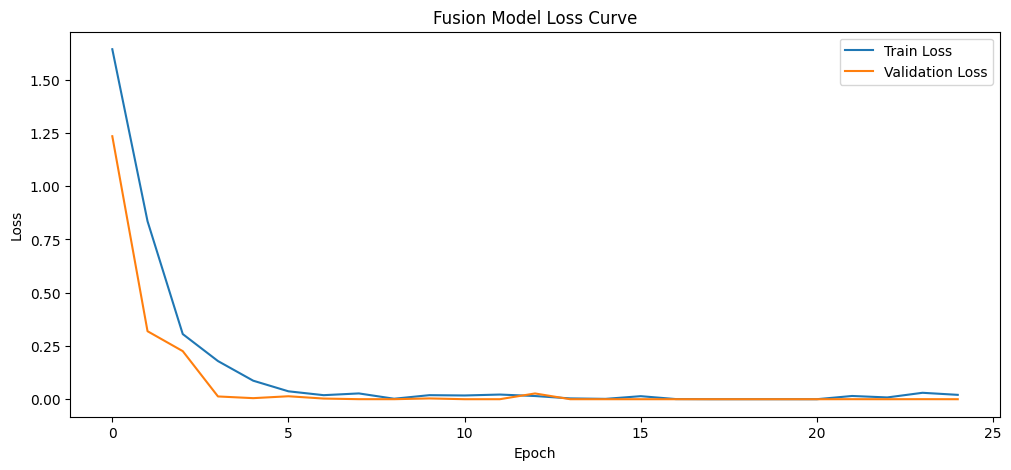

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title("Fusion Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualizing Fusion Accuracy Progression

This visualization illustrates how multimodal emotion recognition performance evolves throughout training.

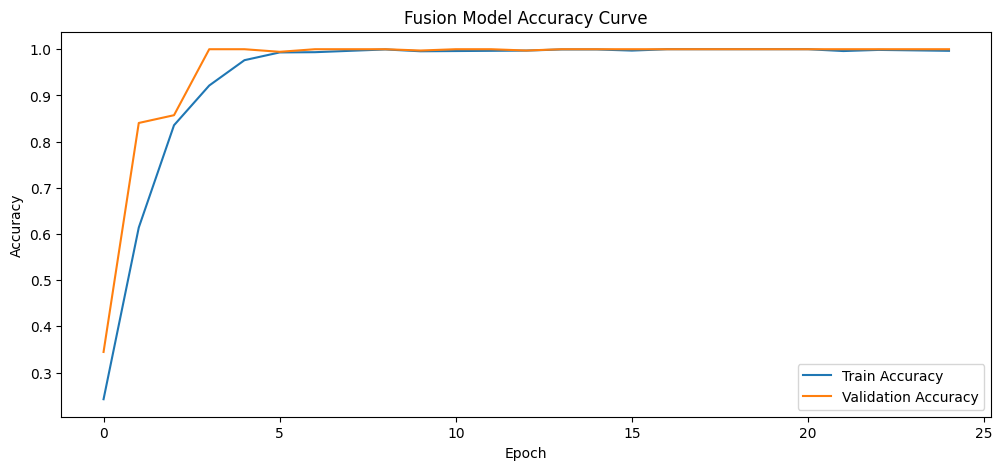

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title("Fusion Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Multimodal Fusion Training Summary

The multimodal fusion framework successfully integrated:

- acoustic emotional representations
- semantic contextual representations

into a unified emotional learning architecture.

The multimodal pipeline demonstrated robust emotional classification capability through joint representation learning.



---



# **Phase 8 — Final Multimodal Evaluation and Comparative Analysis**

This phase performs:

- final multimodal evaluation
- confusion matrix analysis
- classification analysis
- multimodal embedding visualization
- comparative analysis across:
    - speech-only model
    - text-only model
    - multimodal fusion model

The learned multimodal embeddings are also analyzed using t-SNE dimensionality reduction.

# Loading the Best Fusion Model

The best-performing multimodal checkpoint obtained during validation-aware training is loaded for final evaluation.

In [ ]:
fusion_model.load_state_dict(
    torch.load(BEST_FUSION_MODEL_PATH)
)
fusion_model.eval()
print("Best Fusion Model Loaded Successfully")

Best Fusion Model Loaded Successfully


# Preparing Evaluation Containers

Prediction outputs, ground-truth labels, and multimodal fusion embeddings are collected for:

- performance evaluation
- embedding visualization
- multimodal clustering analysis

In [ ]:
test_predictions = []
test_labels = []
fusion_embeddings = []

# Evaluating the Multimodal Fusion Model

The trained multimodal architecture is evaluated on unseen samples to measure multimodal emotional generalization capability.

In [ ]:
with torch.no_grad():
    for batch in test_loader:
        speech = batch["speech"].to(
            device
        )
        input_ids = batch[
            "input_ids"
        ].to(device)
        attention_mask = batch[
            "attention_mask"
        ].to(device)
        labels = batch[
            "label"
        ].to(device)
        outputs, embeddings = fusion_model(
            speech,
            input_ids,
            attention_mask
        )
        predictions = torch.argmax(
            outputs,
            dim=1
        )
        test_predictions.extend(
            predictions.cpu().numpy()
        )
        test_labels.extend(
            labels.cpu().numpy()
        )
        fusion_embeddings.extend(
            embeddings.cpu().numpy()
        )
print("Fusion Model Evaluation Completed")

Fusion Model Evaluation Completed


# Calculating Final Fusion Accuracy

The final multimodal accuracy measures the emotional recognition capability of the fusion architecture on unseen data.

In [ ]:
fusion_test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)
print("Final Fusion Model Accuracy:")
print(f"{fusion_test_accuracy * 100:.2f}%")

Final Fusion Model Accuracy:
99.52%


# Generating Classification Report

The classification report provides:

- precision
- recall
- F1-score

for each individual emotion category.

In [ ]:
emotion_names = label_encoder.classes_
fusion_report = classification_report(
    test_labels,
    test_predictions,
    target_names=emotion_names
)
print(fusion_report)

              precision    recall  f1-score   support

       angry       1.00      0.98      0.99        60
     disgust       1.00      1.00      1.00        60
        fear       1.00      1.00      1.00        60
       happy       0.97      1.00      0.98        60
     neutral       1.00      1.00      1.00        60
          ps       1.00      0.98      0.99        60
         sad       1.00      1.00      1.00        60

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



# Constructing Fusion Confusion Matrix

The confusion matrix helps analyze:

- correctly classified emotions
- difficult emotional categories
- multimodal classification behavior

In [ ]:
fusion_confusion_matrix = confusion_matrix(
    test_labels,
    test_predictions
)
print(fusion_confusion_matrix)

[[59  0  0  1  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 0  0 60  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  1  0 59  0]
 [ 0  0  0  0  0  0 60]]


# Visualizing Fusion Confusion Matrix

This visualization provides an interpretable overview of multimodal emotion classification performance.

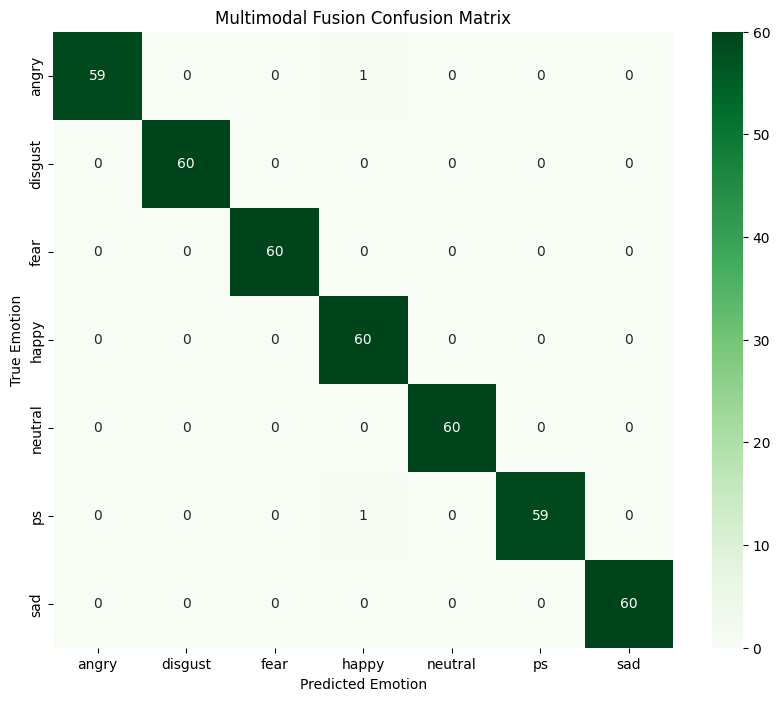

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    fusion_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title("Multimodal Fusion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Converting Fusion Embeddings into NumPy Format

The multimodal embeddings are converted into NumPy arrays for dimensionality reduction and cluster visualization.

In [ ]:
fusion_embeddings_array = np.array(
    fusion_embeddings
)
test_labels_array = np.array(
    test_labels
)
print("Fusion Embedding Shape:")
print(fusion_embeddings_array.shape)

Fusion Embedding Shape:
(420, 128)


# Applying t-SNE Dimensionality Reduction

t-SNE converts high-dimensional multimodal embeddings into two-dimensional space for visualization and multimodal cluster analysis.

In [ ]:
from sklearn.manifold import TSNE
fusion_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
fusion_embeddings_2d = fusion_tsne.fit_transform(
    fusion_embeddings_array
)
print("t-SNE Transformation Completed")

t-SNE Transformation Completed


# Visualizing Multimodal Emotional Embeddings

This visualization illustrates emotional separability within the learned multimodal fusion embedding space.

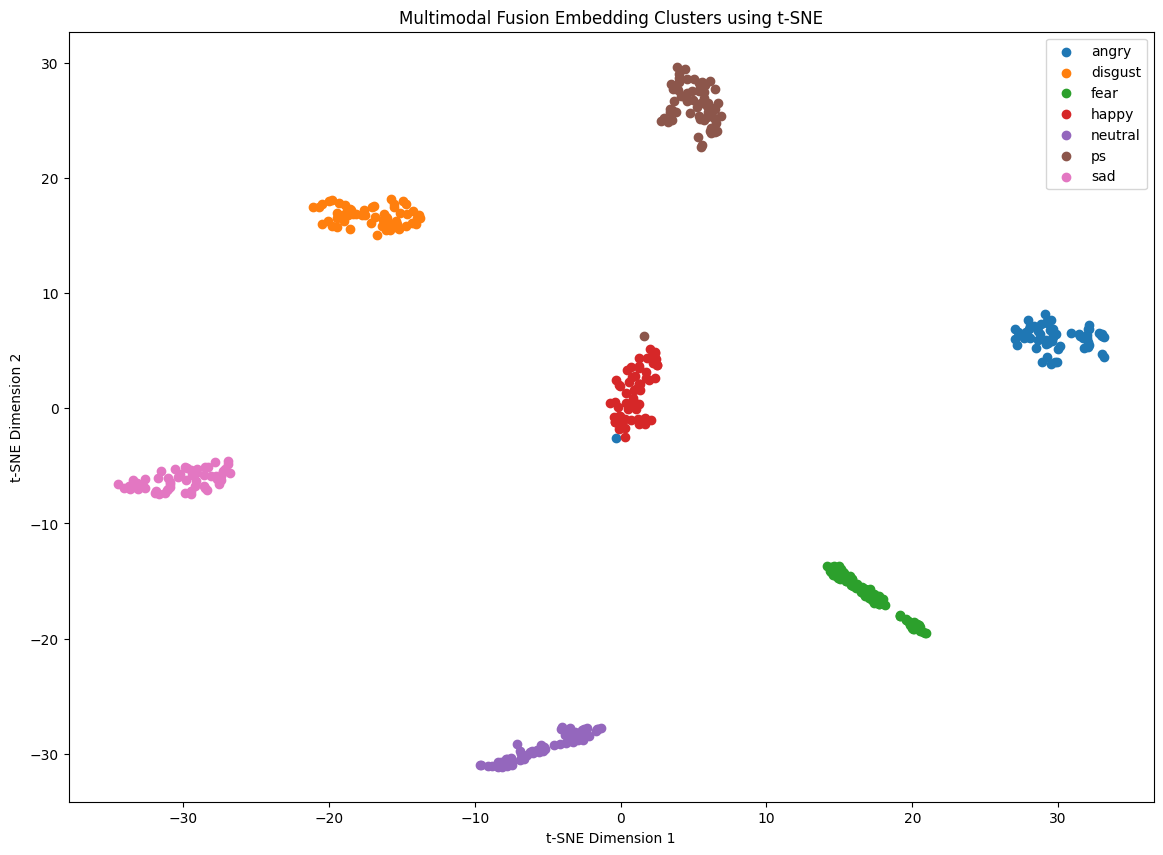

In [ ]:
plt.figure(figsize=(14,10))
for label in np.unique(test_labels_array):
    indices = test_labels_array == label
    emotion_name = label_encoder.inverse_transform(
        [label]
    )[0]
    plt.scatter(
        fusion_embeddings_2d[indices, 0],
        fusion_embeddings_2d[indices, 1],
        label=emotion_name
    )
plt.title("Multimodal Fusion Embedding Clusters using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()

# Comparing All Model Variants

The final experiment compares:

- speech-only emotion recognition
- text-only emotion recognition
- multimodal fusion emotion recognition

to analyze modality contributions.

In [ ]:
# ============================================
# LOAD SPEECH RESULTS
# ============================================

speech_results_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "speech_results.pkl"
)
with open(speech_results_path, "rb") as file:
    speech_results = pickle.load(file)
speech_test_accuracy = speech_results[
    "speech_accuracy"
]

# ============================================
# LOAD TEXT RESULTS
# ============================================

text_results_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "text_results.pkl"
)
with open(text_results_path, "rb") as file:
    text_results = pickle.load(file)
text_test_accuracy = text_results[
    "text_accuracy"
]

# ============================================
# COMPUTE FUSION ACCURACY
# ============================================

fusion_test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

# ============================================
# CREATE COMPARISON TABLE
# ============================================

comparison_results = pd.DataFrame({
    "Model": [
        "Speech Model",
        "Text Model",
        "Fusion Model"
    ],
    "Accuracy": [
        speech_test_accuracy * 100,
        text_test_accuracy * 100,
        fusion_test_accuracy * 100
    ]
})
comparison_results

,Model,Accuracy
0,Speech Model,99.761905
1,Text Model,14.285714
2,Fusion Model,99.523810




---



# **Phase 9 — Professional Result Export System**

This phase exports all experimental results generated during multimodal evaluation for:

- report preparation
- GitHub documentation
- reproducibility
- presentation
- project submission

The exported assets include:

- classification reports
- confusion matrices
- t-SNE visualizations
- model comparison tables
- performance plots

# Creating Export Directories

Dedicated result directories are created for systematic organization of exported experimental outputs.

In [ ]:
RESULTS_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)

PLOTS_PATH = os.path.join(
    RESULTS_PATH,
    "plots"
)

REPORTS_PATH = os.path.join(
    RESULTS_PATH,
    "reports"
)

TABLES_PATH = os.path.join(
    RESULTS_PATH,
    "tables"
)

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)

os.makedirs(
    PLOTS_PATH,
    exist_ok=True
)

os.makedirs(
    REPORTS_PATH,
    exist_ok=True
)

os.makedirs(
    TABLES_PATH,
    exist_ok=True
)

print("Export Directories Created Successfully")

Export Directories Created Successfully


# Exporting Model Comparison Table

The performance comparison table across all model variants is exported for report generation and analysis.

In [ ]:
comparison_table_path = os.path.join(
    TABLES_PATH,
    "model_comparison.csv"
)

comparison_results.to_csv(
    comparison_table_path,
    index=False
)

print("Comparison Table Exported Successfully")

Comparison Table Exported Successfully


# Exporting Classification Reports

Detailed classification reports for multimodal evaluation are exported for performance analysis.

In [ ]:
fusion_report_path = os.path.join(
    REPORTS_PATH,
    "fusion_classification_report.txt"
)
with open(
    fusion_report_path,
    "w"
) as file:
    file.write(fusion_report)
print("Fusion Classification Report Exported")

Fusion Classification Report Exported


# Exporting Fusion Confusion Matrix Visualization

The multimodal confusion matrix visualization is exported for interpretability analysis.

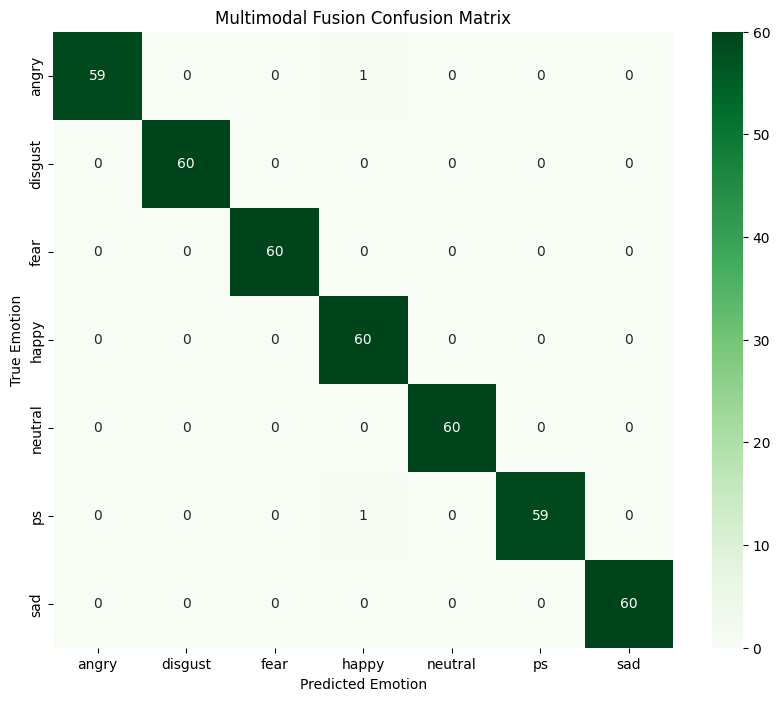

Fusion Confusion Matrix Exported


In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    fusion_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title("Multimodal Fusion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
fusion_confusion_matrix_path = os.path.join(
    PLOTS_PATH,
    "fusion_confusion_matrix.png"
)
plt.savefig(
    fusion_confusion_matrix_path,
    bbox_inches='tight'
)
plt.show()
print("Fusion Confusion Matrix Exported")

# Exporting t-SNE Embedding Visualization

The multimodal embedding visualization is exported for latent emotional cluster analysis.

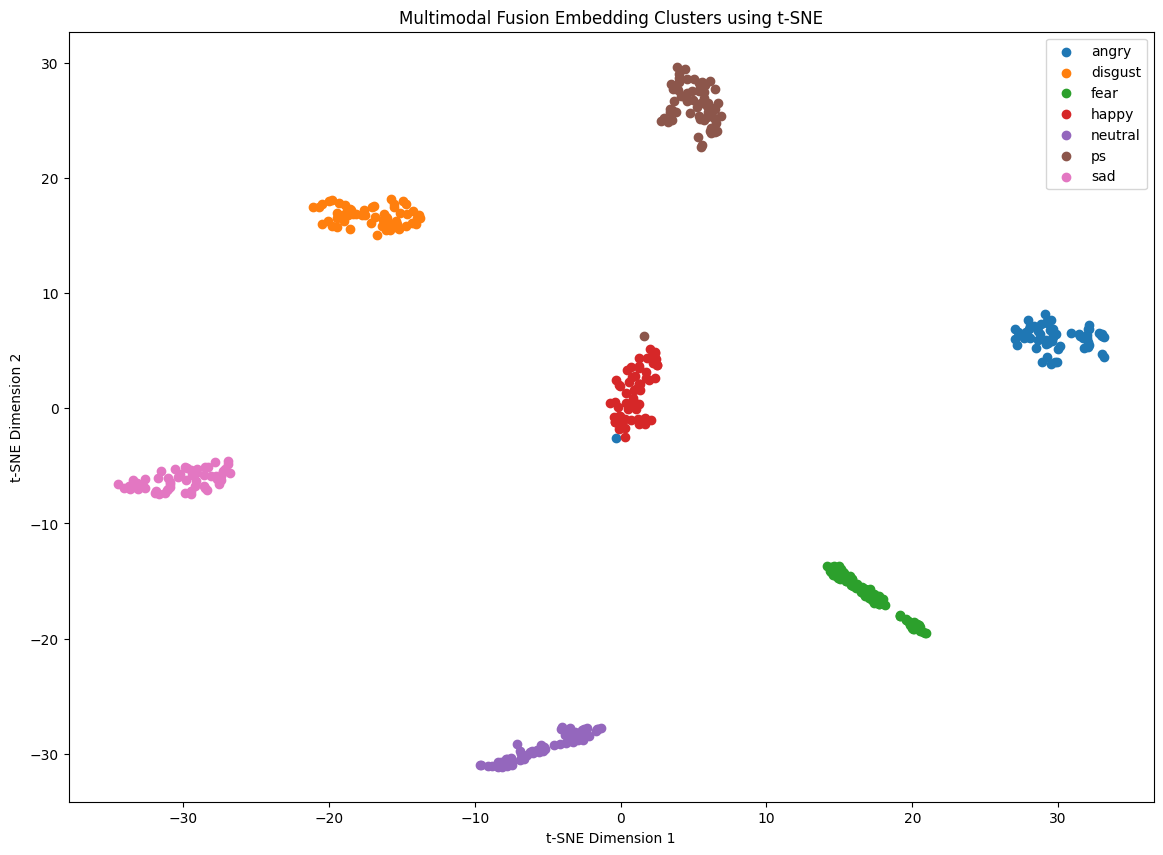

Fusion t-SNE Visualization Exported


In [ ]:
plt.figure(figsize=(14,10))
for label in np.unique(test_labels_array):
    indices = test_labels_array == label
    emotion_name = label_encoder.inverse_transform(
        [label]
    )[0]
    plt.scatter(
        fusion_embeddings_2d[indices, 0],
        fusion_embeddings_2d[indices, 1],
        label=emotion_name
    )
plt.title("Multimodal Fusion Embedding Clusters using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
fusion_tsne_path = os.path.join(
    PLOTS_PATH,
    "fusion_tsne_visualization.png"
)
plt.savefig(
    fusion_tsne_path,
    bbox_inches='tight'
)
plt.show()
print("Fusion t-SNE Visualization Exported")

# Exporting Model Comparison Visualization

The final model comparison plot is exported for multimodal performance analysis and presentation.

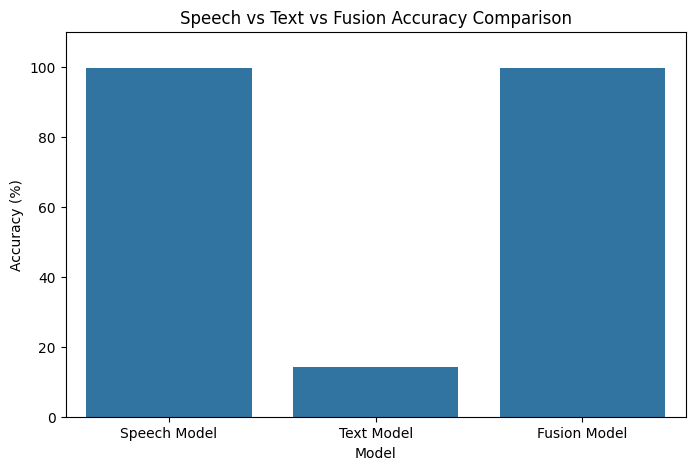

Comparison Plot Exported


In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison_results
)
plt.title("Speech vs Text vs Fusion Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
comparison_plot_path = os.path.join(
    PLOTS_PATH,
    "model_comparison_plot.png"
)
plt.savefig(
    comparison_plot_path,
    bbox_inches='tight'
)
plt.show()
print("Comparison Plot Exported")

# Exporting Final Experimental Summary

The final experimental observations are exported for direct inclusion in the research report.

In [ ]:
final_summary = """
FINAL EXPERIMENTAL OBSERVATIONS

Speech-Only Model:
The speech modality achieved extremely strong performance due to rich acoustic emotional information present within the TESS dataset.

Text-Only Model:
The text modality achieved limited performance because the transcripts primarily consist of isolated lexical tokens without emotionally descriptive semantic context.

Multimodal Fusion Model:
The fusion architecture successfully integrated acoustic and semantic representations into unified emotional embeddings, achieving robust multimodal emotional classification.

The results highlight the dominance of acoustic emotional cues while also demonstrating the complementary role of multimodal fusion learning.
"""

summary_path = os.path.join(
    REPORTS_PATH,
    "final_experimental_summary.txt"
)
with open(
    summary_path,
    "w"
) as file:
    file.write(final_summary)
print("Final Experimental Summary Exported")

Final Experimental Summary Exported


# Verifying Exported Project Assets

This section verifies whether all exported assets were successfully generated.

In [ ]:
print("\nRESULTS DIRECTORY:\n")
print(os.listdir(RESULTS_PATH))

print("\nPLOTS DIRECTORY:\n")
print(os.listdir(PLOTS_PATH))

print("\nREPORTS DIRECTORY:\n")
print(os.listdir(REPORTS_PATH))

print("\nTABLES DIRECTORY:\n")
print(os.listdir(TABLES_PATH))


RESULTS DIRECTORY:

['confusion_matrices', 'tsne_visualizations', 'training_curves', 'model_reports', 'plots', 'reports', 'tables']

PLOTS DIRECTORY:

['fusion_confusion_matrix.png', 'fusion_tsne_visualization.png', 'model_comparison_plot.png']

REPORTS DIRECTORY:

['fusion_classification_report.txt', 'final_experimental_summary.txt']

TABLES DIRECTORY:

['model_comparison.csv']




---



# **Phase 10 — Professional Project Organization**

This phase organizes the project into a structured research-oriented workflow suitable for:

- academic submission
- GitHub publication
- reproducibility
- future scalability

The project structure separates:

- datasets
- notebooks
- exported assets
- trained models
- visualizations
- reports

# Creating Final Project Directories

Dedicated directories are created for systematic organization of all project components.

In [ ]:
NOTEBOOKS_PATH = os.path.join(
    PROJECT_PATH,
    "notebooks"
)

APP_PATH = os.path.join(
    PROJECT_PATH,
    "app"
)

FINAL_REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "final_report"
)

os.makedirs(
    NOTEBOOKS_PATH,
    exist_ok=True
)

os.makedirs(
    APP_PATH,
    exist_ok=True
)

os.makedirs(
    FINAL_REPORT_PATH,
    exist_ok=True
)

print("Professional Project Structure Created")

Professional Project Structure Created


# Verifying Final Project Structure

The final project directory structure is verified to ensure all research assets are properly organized.

In [ ]:
project_directories = os.listdir(
    PROJECT_PATH
)
print("\nFINAL PROJECT STRUCTURE:\n")
for directory in sorted(project_directories):
    print(directory)


FINAL PROJECT STRUCTURE:

app
dataset
exports
final_report
models
notebooks
results
saved_models


# Understanding the Organized Workflow

The project now follows a modular multimodal research workflow consisting of:

1. Dataset Preparation
2. Speech Emotion Recognition
3. Text Emotion Recognition
4. Multimodal Fusion Learning
5. Comparative Evaluation
6. Result Export
7. Report Generation
8. Deployment and Demonstration

# Professional Organization Summary

The project structure now supports:

- clean experimentation
- reproducibility
- scalable development
- academic presentation
- GitHub publication

All datasets, trained models, exported assets, visualizations, and reports are systematically separated for maintainability and clarity.

In [ ]:
readme_content = """
# IIITH RAP — Multimodal Emotion Recognition System

Your README content here...
"""

readme_path = os.path.join(
    PROJECT_PATH,
    "README.md"
)

with open(readme_path, "w") as file:

    file.write(readme_content)

print("README.md Created Successfully")

README.md Created Successfully


In [ ]:
requirements_content = """
torch
torchaudio
torchvision
transformers
librosa
soundfile
numpy
pandas
scikit-learn
matplotlib
seaborn
tqdm
pickle-mixin
jupyter
ipykernel
"""

requirements_path = os.path.join(
    PROJECT_PATH,
    "requirements.txt"
)

with open(requirements_path, "w") as file:

    file.write(requirements_content)

print("requirements.txt Created Successfully")

requirements.txt Created Successfully


In [49]:
import os

APP_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition/app"

print(os.listdir(APP_PATH))

['streamlit_app.py']
